
# Earth Systems Playground, Part 4: What If Climate Data Were a Function, Not a Grid?

This notebook merges two experiments into one narrative:

- **Part A** (small scale): a SIREN trained on ~1 week of ERA5 2m temperature over a small
  Marmara/Istanbul patch. Tests basic reconstruction accuracy, compression ratio, and — more
  interestingly — capabilities a stored array doesn't have: continuous super-resolution query,
  time interpolation, and differentiable spatial gradients.
- **Part B** (large scale, architecture sweep): the same idea scaled up (~125x more data: wider
  region, one full month, hourly) with a sweep of small SIREN architectures, float16
  quantization, and a fair multi-point PCA comparison — testing specifically whether INR
  compression can be made to actually win against a classical baseline, and where.

Both parts are extended with error-bound and distortion metrics modeled on
**[ClimateBenchPress (Reichelt, Tyree, Klöwer, Dueben, Lawrence, Baker, Faghih-Naini, Hoefler,
Stier — GMD 2026)](https://doi.org/10.5194/gmd-19-5933-2026)**, a benchmark for lossy
compression of climate data:

- **Physically grounded error bounds**, derived from ERA5's own ensemble spread (uncertainty
  estimate) rather than an arbitrary RMSE threshold — following ClimateBenchPress Eq. (1)-(2).
- **MaxAbsError**, to check whether any single point blows up even when RMSE looks fine.
- **Spectral Error (RAPSD)**, to check whether high-frequency spatial detail is preserved, not
  just average error — following the pysteps radially-averaged power spectral density convention
  used in ClimateBenchPress Sect. 2.3.1.
- **Rate-distortion / Pareto-style reporting**, annotating the Part B architecture sweep with
  pass/fail against each error bound, so "best compression" is reported *conditional on staying
  within a defensible error tolerance*, not just as a raw ratio.

> **Security note:** this notebook reads your CDS API key from **Colab Secrets**, never as a
> hardcoded string. Add a secret named `CDS_API_KEY` (key icon in the left sidebar) before running
> the data cells, and grant this notebook access to it.
>
> **If you previously ran a version of this notebook with a hardcoded API key, rotate that key
> in your CDS account before publishing this notebook anywhere.**


## 1. Setup

In [ ]:

!pip install cdsapi xarray netCDF4 torch matplotlib scikit-learn -q


In [ ]:

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Global config ---
USE_SYNTHETIC_DATA = False  # set True only for a quick structural smoke-test without a CDS key

# --- Part A: small-scale region/period ---
REGION_A = {"lat_min": 40.0, "lat_max": 41.5, "lon_min": 27.5, "lon_max": 29.5}
DATE_RANGE_A = ("2026-06-01", "2026-06-07")   # one week
GRID_RES = 0.25  # degrees, matches typical ERA5 single-levels resolution

# --- Part B: large-scale region/period ---
REGION_B = {"lat_min": 38.5, "lat_max": 42.5, "lon_min": 26.0, "lon_max": 31.0}
DATE_RANGE_B = ("2026-06-01", "2026-06-30")   # one month

# --- Caching ---
# Downloaded NetCDF files are cached to disk by a deterministic filename, so re-running
# a cell (or re-running the notebook in a fresh session with the same /content path, or a
# mounted Drive path) does not re-download data you already have. If you already have ERA5
# files downloaded from earlier runs, either drop them in DATA_DIR with matching filenames
# (see fetch_era5_t2m below for the naming pattern) or point DATA_DIR at the folder that
# contains them.
DATA_DIR = "/content/era5_cache"
os.makedirs(DATA_DIR, exist_ok=True)

# Optional: mount Google Drive for a cache that survives across Colab sessions.
# Uncomment to use -- this will prompt for Drive authorization.
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = "/content/drive/MyDrive/era5_cache"
# os.makedirs(DATA_DIR, exist_ok=True)

print(f"Data cache directory: {DATA_DIR}")


Using device: cuda
Data cache directory: /content/era5_cache



## 2. Data fetching (shared between Part A and Part B, with local caching)

### CDS API key setup

`cdsapi.Client()` can take credentials directly as constructor arguments, avoiding any need to
write `~/.cdsapirc` to disk. The key is read from **Colab Secrets** at runtime and never
hardcoded.


In [ ]:

def get_cds_credentials():
    """Read CDS API credentials from Colab Secrets. Returns (url, key) or (None, None)
    if unavailable, in which case cdsapi.Client() will fall back to ~/.cdsapirc if present."""
    try:
        from google.colab import userdata
    except ImportError:
        print("Not running in Colab -- cdsapi.Client() will look for ~/.cdsapirc instead.")
        return None, None

    try:
        api_key = userdata.get("CDS_API_KEY")
    except Exception:
        print("No CDS_API_KEY found in Colab Secrets -- add it via the key icon in the left "
              "sidebar before running with USE_SYNTHETIC_DATA = False.")
        return None, None

    try:
        api_url = userdata.get("CDS_API_URL")
    except Exception:
        api_url = "https://cds.climate.copernicus.eu/api"

    return api_url, api_key


_cds_url, _cds_key = get_cds_credentials()


In [ ]:

def build_grid(region, res):
    lats = np.arange(region["lat_min"], region["lat_max"] + res, res)
    lons = np.arange(region["lon_min"], region["lon_max"] + res, res)
    return lats, lons


def synthetic_t2m_field(lats, lons, n_time):
    """Smooth synthetic fallback field, shape (n_lat, n_lon, n_time). For structural
    smoke-testing only -- the real experiments need real ERA5 data."""
    LAT, LON, T = np.meshgrid(lats, lons, np.arange(n_time), indexing="ij")
    spatial = 22 + 3 * (LAT.max() - LAT) + 1.5 * (LON - LON.min())
    diurnal = 4 * np.sin(2 * np.pi * (T % 24 - 6) / 24)
    seasonal_drift = 0.02 * T
    noise = np.random.normal(0, 0.3, size=LAT.shape)
    return spatial + diurnal + seasonal_drift + noise


def _cache_path(prefix, region, date_range, res):
    tag = (f"{prefix}_{region['lat_min']}_{region['lat_max']}_{region['lon_min']}_"
           f"{region['lon_max']}_{date_range[0]}_{date_range[1]}_{res}").replace(".", "p")
    return os.path.join(DATA_DIR, tag + ".nc")


def fetch_era5_t2m(region, date_range, res, cds_url=None, cds_key=None, use_cache=True):
    """Pull ERA5 2m temperature (reanalysis) for a region/date range, all hours.
    Returns (values, lats, lons) with values ordered (lat, lon, time).
    Caches the raw NetCDF file to DATA_DIR so repeated calls (or re-running the notebook
    against the same cache directory / a mounted Drive folder) skip the CDS request."""
    import xarray as xr

    nc_path = _cache_path("t2m", region, date_range, res)

    if not (use_cache and os.path.exists(nc_path)):
        import cdsapi
        c = cdsapi.Client(url=cds_url, key=cds_key) if (cds_url and cds_key) else cdsapi.Client()
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": "2m_temperature",
                "date": f"{date_range[0]}/{date_range[1]}",
                "time": [f"{h:02d}:00" for h in range(24)],
                "area": [region["lat_max"], region["lon_min"], region["lat_min"], region["lon_max"]],
                "grid": [res, res],
                "format": "netcdf",
            },
            nc_path,
        )
        print(f"Downloaded and cached: {nc_path}")
    else:
        print(f"Using cached file: {nc_path}")

    ds = xr.open_dataset(nc_path)
    da = ds["t2m"] - 273.15  # Kelvin -> Celsius

    time_dim = "time" if "time" in da.dims else "valid_time"
    da = da.transpose("latitude", "longitude", time_dim)

    return da.values, da["latitude"].values, da["longitude"].values


def fetch_era5_ensemble_spread(region, date_range, res, cds_url=None, cds_key=None, use_cache=True):
    """Pull ERA5 2m temperature ensemble spread (uncertainty estimate) for the same
    region/dates, following ClimateBenchPress's approach of deriving error bounds from
    ensemble spread percentiles (Reichelt et al. 2026, Sect. 2.2). Cached like fetch_era5_t2m."""
    import xarray as xr

    nc_path = _cache_path("t2m_spread", region, date_range, res)

    if not (use_cache and os.path.exists(nc_path)):
        import cdsapi
        c = cdsapi.Client(url=cds_url, key=cds_key) if (cds_url and cds_key) else cdsapi.Client()
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "ensemble_spread",
                "variable": "2m_temperature",
                "date": f"{date_range[0]}/{date_range[1]}",
                "time": [f"{h:02d}:00" for h in range(24)],
                "area": [region["lat_max"], region["lon_min"], region["lat_min"], region["lon_max"]],
                "grid": [res, res],
                "format": "netcdf",
            },
            nc_path,
        )
        print(f"Downloaded and cached: {nc_path}")
    else:
        print(f"Using cached file: {nc_path}")

    ds = xr.open_dataset(nc_path)
    da = ds["t2m"]  # ensemble spread is already a magnitude in Kelvin (no offset needed)

    time_dim = "time" if "time" in da.dims else "valid_time"
    da = da.transpose("latitude", "longitude", time_dim)
    return da.values


def to_lat_lon_time(arr, data_lats=None, data_lons=None):
    """Normalize an array to this notebook's single convention: shape (n_lat, n_lon, n_time).
    Handles the common ERA5 (time, lat, lon) ordering as well as pre-flattened (lat, lon, time)."""
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 3 and data_lats is not None and data_lons is not None:
        if arr.shape[1] == len(data_lats) and arr.shape[2] == len(data_lons):
            arr = arr.transpose(1, 2, 0)
    return arr


def compute_error_bounds(spread):
    """Compute the three ClimateBenchPress-style error bounds (low/mid/high) from an
    ensemble spread array, following Reichelt et al. 2026 Eq. (1): percentiles of the
    non-zero ensemble spread distribution."""
    nonzero_spread = spread[spread > 0].ravel()
    b_low = np.percentile(nonzero_spread, 0)
    b_mid = np.percentile(nonzero_spread, 1)
    b_high = np.percentile(nonzero_spread, 5)
    return b_low, b_mid, b_high



## 3. SIREN model + shared utilities (metrics, error bounds, spectral error)


In [ ]:

class SIREN(nn.Module):
    """Minimal SIREN: MLP with sinusoidal activations (Sitzmann et al., 2020)."""
    def __init__(self, in_dim, hidden_dim=64, n_layers=4, out_dim=1, w0=30.0):
        super().__init__()
        self.w0 = w0
        layers = [nn.Linear(in_dim, hidden_dim)]
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.hidden_layers = nn.ModuleList(layers)
        self.out_layer = nn.Linear(hidden_dim, out_dim)
        self._siren_init()

    def _siren_init(self):
        with torch.no_grad():
            first = True
            for layer in self.hidden_layers:
                fan_in = layer.weight.shape[1]
                bound = (1 / fan_in) if first else (np.sqrt(6 / fan_in) / self.w0)
                layer.weight.uniform_(-bound, bound)
                first = False
            fan_in = self.out_layer.weight.shape[1]
            self.out_layer.weight.uniform_(-np.sqrt(6 / fan_in) / self.w0, np.sqrt(6 / fan_in) / self.w0)

    def forward(self, coords):
        x = coords
        for layer in self.hidden_layers:
            x = torch.sin(self.w0 * layer(x))
        return self.out_layer(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def model_size_bytes(model, dtype_bytes=4):
    return count_params(model) * dtype_bytes


def max_abs_error(original, reconstructed):
    """ClimateBenchPress MaxAbsError: does any single point blow up, even if RMSE looks fine?"""
    return np.max(np.abs(original - reconstructed))


def radially_averaged_psd(field_2d):
    """Radially averaged power spectral density of a 2D field (pysteps convention,
    as used in ClimateBenchPress Sect. 2.3.1)."""
    F = np.fft.fftshift(np.fft.fft2(field_2d))
    psd2d = (np.abs(F) ** 2) / field_2d.size
    ny, nx = field_2d.shape
    cy, cx = ny // 2, nx // 2
    y, x = np.indices((ny, nx))
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2).astype(int)
    r_max = r.max()
    return np.array([psd2d[r == i].mean() if np.any(r == i) else 0 for i in range(r_max + 1)])


def spectral_error(original, reconstructed):
    """ClimateBenchPress-style Spectral Error: sum of squared differences between RAPSD
    curves, averaged over all time steps. Checks whether high-frequency spatial detail is
    preserved, which a pointwise metric like RMSE can miss."""
    n_t = original.shape[-1]
    errors = []
    for t in range(n_t):
        s_orig = radially_averaged_psd(original[:, :, t])
        s_recon = radially_averaged_psd(reconstructed[:, :, t])
        min_len = min(len(s_orig), len(s_recon))
        errors.append(np.sum((s_orig[:min_len] - s_recon[:min_len]) ** 2))
    return np.mean(errors)


def report_against_bounds(rmse, b_low, b_mid, b_high, label="Model"):
    print(f"{label} RMSE: {rmse:.4f} °C")
    for name, bound in [("b_low (strict)", b_low), ("b_mid (medium)", b_mid), ("b_high (lenient)", b_high)]:
        status = "PASSES" if rmse <= bound else "exceeds"
        ratio = rmse / bound if bound > 0 else float("inf")
        print(f"  vs {name} ({bound:.4f} °C): {status} ({ratio:.2f}x the bound)")



---
# Part A: Small-scale experiment

A ~1.5°x2° patch around Istanbul, one week of hourly 2m temperature. Tests basic reconstruction
accuracy and compression, plus INR-specific capabilities: super-resolution query, time
interpolation, and differentiable gradients.


## A.1 Data

In [ ]:

lats_A, lons_A = build_grid(REGION_A, GRID_RES)

if USE_SYNTHETIC_DATA:
    print("Using synthetic fallback data -- for structural testing only.")
    field_A = synthetic_t2m_field(lats_A, lons_A, 24 * 7)
else:
    raw_A, data_lats_A, data_lons_A = fetch_era5_t2m(REGION_A, DATE_RANGE_A, GRID_RES,
                                                       cds_url=_cds_url, cds_key=_cds_key)
    field_A = to_lat_lon_time(raw_A, data_lats_A, data_lons_A)
    lats_A, lons_A = data_lats_A, data_lons_A

n_lat_A, n_lon_A, n_time_A = field_A.shape
print(f"Part A field shape (lat, lon, time): {field_A.shape}")


2026-07-09 09:41:09,390 INFO Request ID is 7a719285-83d6-475f-8c61-fffad79faf78
INFO:ecmwf.datastores.legacy_client:Request ID is 7a719285-83d6-475f-8c61-fffad79faf78
2026-07-09 09:41:09,603 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-09 09:41:24,051 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-09 09:41:33,343 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


2e621aed871eaacf9769629c149788f5.nc:   0%|          | 0.00/51.5k [00:00<?, ?B/s]

Downloaded and cached: /content/era5_cache/t2m_40p0_41p5_27p5_29p5_2026-06-01_2026-06-07_0p25.nc
Part A field shape (lat, lon, time): (7, 9, 168)


## A.2 Stage 1 — static case: single time slice, 2D (lat, lon) → temperature

In [ ]:

stage1_time_idx = min(14, n_time_A - 1)  # 14:00 if available
target_2d = field_A[:, :, stage1_time_idx]

lat_idx_A = np.arange(n_lat_A)
lon_idx_A = np.arange(n_lon_A)
lat_grid, lon_grid = np.meshgrid(lat_idx_A, lon_idx_A, indexing="ij")

lat_norm = 2 * (lat_grid - lat_idx_A.min()) / max(lat_idx_A.max() - lat_idx_A.min(), 1) - 1
lon_norm = 2 * (lon_grid - lon_idx_A.min()) / max(lon_idx_A.max() - lon_idx_A.min(), 1) - 1

coords = np.stack([lat_norm.ravel(), lon_norm.ravel()], axis=-1)
values = target_2d.ravel()

val_mean, val_std = values.mean(), values.std()
if val_std == 0:
    val_std = 1.0
values_norm = (values - val_mean) / val_std

coords_t = torch.tensor(coords, dtype=torch.float32, device=device)
values_t = torch.tensor(values_norm, dtype=torch.float32, device=device).unsqueeze(-1)

print("Stage 1 grid:", target_2d.shape, "-> total points:", coords.shape[0])


Stage 1 grid: (7, 9) -> total points: 63


epoch    0 | loss 1.020831
epoch  400 | loss 0.003517
epoch  800 | loss 0.000452
epoch 1200 | loss 0.000145
epoch 1600 | loss 0.000036


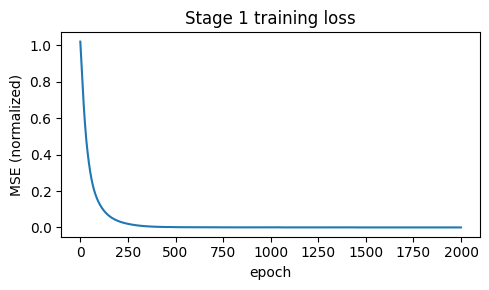

In [ ]:

model_stage1 = SIREN(in_dim=2, hidden_dim=64, n_layers=4).to(device)
optimizer = torch.optim.Adam(model_stage1.parameters(), lr=1e-4)
n_epochs = 2000

losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model_stage1(coords_t)
    loss = nn.functional.mse_loss(pred, values_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 400 == 0:
        print(f"epoch {epoch:4d} | loss {loss.item():.6f}")

plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.title("Stage 1 training loss")
plt.xlabel("epoch"); plt.ylabel("MSE (normalized)")
plt.tight_layout()
plt.savefig("stage_1_train_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:

with torch.no_grad():
    recon_norm = model_stage1(coords_t).cpu().numpy().reshape(n_lat_A, n_lon_A)
recon = recon_norm * val_std + val_mean

rmse_stage1 = np.sqrt(np.mean((recon - target_2d) ** 2))
print(f"Stage 1 RMSE: {rmse_stage1:.4f} °C")

original_size = target_2d.size * 4
model_size = count_params(model_stage1) * 4
compression_ratio = original_size / model_size
print(f"Original grid size: {original_size} bytes ({target_2d.size} values)")
print(f"Model size: {model_size} bytes ({count_params(model_stage1)} parameters)")
print(f"Compression ratio: {compression_ratio:.2f}x")


Stage 1 RMSE: 0.0078 °C
Original grid size: 252 bytes (63 values)
Model size: 50948 bytes (12737 parameters)
Compression ratio: 0.00x


## A.3 Stage 2 — spatio-temporal: (lat, lon, time) → temperature, full week

In [ ]:

field_flat_time = field_A
time_index = np.arange(n_time_A)

LAT3, LON3, TIME3 = np.meshgrid(lat_idx_A, lon_idx_A, time_index, indexing="ij")
lat3_norm = 2 * (LAT3 - lat_idx_A.min()) / max(lat_idx_A.max() - lat_idx_A.min(), 1) - 1
lon3_norm = 2 * (LON3 - lon_idx_A.min()) / max(lon_idx_A.max() - lon_idx_A.min(), 1) - 1
time3_norm = 2 * (TIME3 - time_index.min()) / max(time_index.max() - time_index.min(), 1) - 1

coords3 = np.stack([lat3_norm.ravel(), lon3_norm.ravel(), time3_norm.ravel()], axis=-1)
values3 = field_flat_time.ravel()

val3_mean, val3_std = values3.mean(), values3.std()
if val3_std == 0:
    val3_std = 1.0
values3_norm = (values3 - val3_mean) / val3_std

coords3_t = torch.tensor(coords3, dtype=torch.float32, device=device)
values3_t = torch.tensor(values3_norm, dtype=torch.float32, device=device).unsqueeze(-1)

print("Stage 2 total points:", coords3.shape[0], "(", n_lat_A, "x", n_lon_A, "x", n_time_A, ")")


Stage 2 total points: 10584 ( 7 x 9 x 168 )


epoch    0 | loss 0.967055
epoch  500 | loss 0.011322
epoch 1000 | loss 0.005607
epoch 1500 | loss 0.003635
epoch 2000 | loss 0.002533
epoch 2500 | loss 0.001625


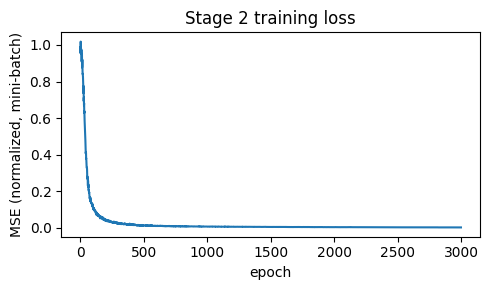

In [ ]:

model_stage2 = SIREN(in_dim=3, hidden_dim=96, n_layers=5).to(device)
optimizer2 = torch.optim.Adam(model_stage2.parameters(), lr=1e-4)
n_epochs2 = 3000
batch_size = 4096
n_points = coords3_t.shape[0]

losses2 = []
for epoch in range(n_epochs2):
    idx = torch.randint(0, n_points, (batch_size,), device=device)
    optimizer2.zero_grad()
    pred = model_stage2(coords3_t[idx])
    loss = nn.functional.mse_loss(pred, values3_t[idx])
    loss.backward()
    optimizer2.step()
    losses2.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:4d} | loss {loss.item():.6f}")

plt.figure(figsize=(5, 3))
plt.plot(losses2)
plt.title("Stage 2 training loss")
plt.xlabel("epoch"); plt.ylabel("MSE (normalized, mini-batch)")
plt.tight_layout()
plt.savefig("stage_2_train_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:

with torch.no_grad():
    preds = []
    chunk = 20000
    for i in range(0, n_points, chunk):
        preds.append(model_stage2(coords3_t[i:i+chunk]).cpu().numpy())
    recon3_norm = np.concatenate(preds).reshape(n_lat_A, n_lon_A, n_time_A)
recon3 = recon3_norm * val3_std + val3_mean

rmse_stage2 = np.sqrt(np.mean((recon3 - field_flat_time) ** 2))
print(f"Stage 2 RMSE: {rmse_stage2:.4f} °C")

original_size2 = field_flat_time.size * 4
model_size2 = count_params(model_stage2) * 4
compression_ratio2 = original_size2 / model_size2
print(f"Original data size: {original_size2} bytes ({field_flat_time.size} values)")
print(f"Model size: {model_size2} bytes ({count_params(model_stage2)} parameters)")
print(f"Compression ratio: {compression_ratio2:.2f}x")


Stage 2 RMSE: 0.1227 °C
Original data size: 42336 bytes (10584 values)
Model size: 150916 bytes (37729 parameters)
Compression ratio: 0.28x



## A.4 ClimateBenchPress-style evaluation: error bounds, MaxAbsError, Spectral Error

Instead of judging RMSE against an arbitrary threshold, derive a physically grounded error
bound from ERA5's own ensemble spread (uncertainty estimate), following Reichelt et al. 2026
(ClimateBenchPress) Eq. (1)-(2). Also add MaxAbsError and Spectral Error (RAPSD) to check for
failure modes RMSE alone can hide: single-point blowups and loss of high-frequency detail.


In [ ]:

if USE_SYNTHETIC_DATA:
    print("Skipping real error-bound derivation under synthetic data.")
    b_low_A = b_mid_A = b_high_A = None
else:
    spread_A = fetch_era5_ensemble_spread(REGION_A, DATE_RANGE_A, GRID_RES,
                                           cds_url=_cds_url, cds_key=_cds_key)
    spread_A = to_lat_lon_time(spread_A, lats_A, lons_A)
    b_low_A, b_mid_A, b_high_A = compute_error_bounds(spread_A)

    print("Error bounds derived from ERA5 ensemble spread (ClimateBenchPress method):")
    print(f"  b_low  (strict):  {b_low_A:.4f} °C")
    print(f"  b_mid  (medium):  {b_mid_A:.4f} °C")
    print(f"  b_high (lenient): {b_high_A:.4f} °C")
    print()
    report_against_bounds(rmse_stage2, b_low_A, b_mid_A, b_high_A, label="Stage 2 SIREN")


2026-07-09 09:41:49,351 INFO Request ID is 2aa85e42-cbe7-4fac-95ca-2b2551182fd1
INFO:ecmwf.datastores.legacy_client:Request ID is 2aa85e42-cbe7-4fac-95ca-2b2551182fd1
2026-07-09 09:41:49,535 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-09 09:41:58,960 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-09 09:42:12,013 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


7f3ca8ab40d18a3dfe22069f6111fa97.nc:   0%|          | 0.00/33.4k [00:00<?, ?B/s]

Downloaded and cached: /content/era5_cache/t2m_spread_40p0_41p5_27p5_29p5_2026-06-01_2026-06-07_0p25.nc
Error bounds derived from ERA5 ensemble spread (ClimateBenchPress method):
  b_low  (strict):  0.1079 °C
  b_mid  (medium):  0.1443 °C
  b_high (lenient): 0.1776 °C

Stage 2 SIREN RMSE: 0.1227 °C
  vs b_low (strict) (0.1079 °C): exceeds (1.14x the bound)
  vs b_mid (medium) (0.1443 °C): PASSES (0.85x the bound)
  vs b_high (lenient) (0.1776 °C): PASSES (0.69x the bound)


In [ ]:

max_err_A = max_abs_error(field_flat_time, recon3)
spec_err_A = spectral_error(field_flat_time, recon3)

print(f"Stage 2 SIREN -- MaxAbsError: {max_err_A:.4f} °C  (RMSE was {rmse_stage2:.4f} °C)")
print(f"Stage 2 SIREN -- Spectral Error (RAPSD, ClimateBenchPress convention): {spec_err_A:.6f}")


Stage 2 SIREN -- MaxAbsError: 0.8285 °C  (RMSE was 0.1227 °C)
Stage 2 SIREN -- Spectral Error (RAPSD, ClimateBenchPress convention): 23571.628906


## A.5 Baseline comparison: PCA (single setting)

In [ ]:

X_A = field_flat_time.reshape(n_lat_A * n_lon_A, n_time_A).T
n_components_A = min(5, X_A.shape[0], X_A.shape[1])
pca_A = PCA(n_components=n_components_A)
X_reduced_A = pca_A.fit_transform(X_A)
X_reconstructed_A = pca_A.inverse_transform(X_reduced_A)

rmse_pca_A = np.sqrt(np.mean((X_reconstructed_A - X_A) ** 2))
pca_size_A = (pca_A.components_.size + pca_A.mean_.size + X_reduced_A.size) * 4
compression_ratio_pca_A = original_size2 / pca_size_A

print(f"PCA RMSE ({n_components_A} components): {rmse_pca_A:.4f} °C")
print(f"PCA representation size: {pca_size_A} bytes")
print(f"PCA compression ratio: {compression_ratio_pca_A:.2f}x")

print("\n--- Part A summary ---")
print(f"{'Method':<20}{'RMSE (°C)':<15}{'Compression ratio':<20}")
print(f"{'SIREN (Stage 2)':<20}{rmse_stage2:<15.4f}{compression_ratio2:<20.2f}")
print(f"{'PCA (' + str(n_components_A) + ' comps)':<20}{rmse_pca_A:<15.4f}{compression_ratio_pca_A:<20.2f}")

if not USE_SYNTHETIC_DATA:
    print()
    report_against_bounds(rmse_pca_A, b_low_A, b_mid_A, b_high_A, label="PCA")


PCA RMSE (5 components): 0.3839 °C
PCA representation size: 4872 bytes
PCA compression ratio: 8.69x

--- Part A summary ---
Method              RMSE (°C)      Compression ratio   
SIREN (Stage 2)     0.1227         0.28                
PCA (5 comps)       0.3839         8.69                

PCA RMSE: 0.3839 °C
  vs b_low (strict) (0.1079 °C): exceeds (3.56x the bound)
  vs b_mid (medium) (0.1443 °C): exceeds (2.66x the bound)
  vs b_high (lenient) (0.1776 °C): exceeds (2.16x the bound)



## A.6 Diagnostics: Fourier spectrum, spatial correlation, Taylor diagram


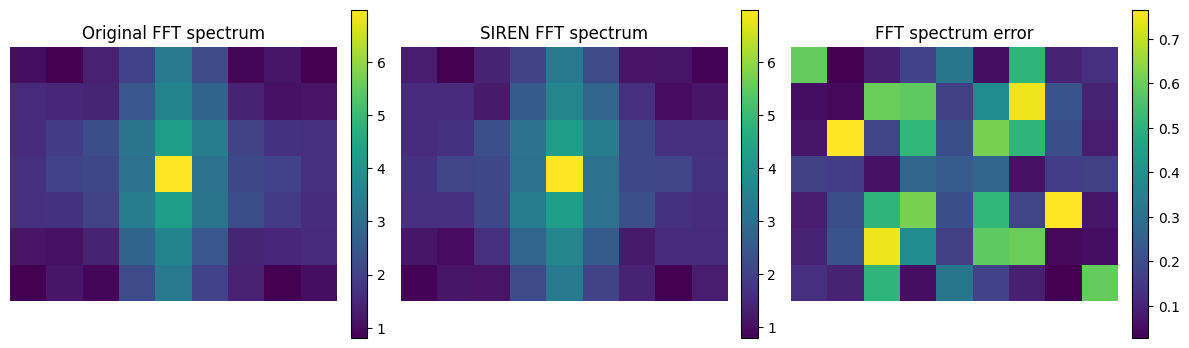

In [ ]:

t_show = 0
true_2d = field_flat_time[:, :, t_show]
recon_2d = recon3[:, :, t_show]

fft_true = np.fft.fftshift(np.abs(np.fft.fft2(true_2d)))
fft_recon = np.fft.fftshift(np.abs(np.fft.fft2(recon_2d)))
fft_error = np.abs(fft_recon - fft_true)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(np.log1p(fft_true)); axes[0].set_title("Original FFT spectrum"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(np.log1p(fft_recon)); axes[1].set_title("SIREN FFT spectrum"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(np.log1p(fft_error)); axes[2].set_title("FFT spectrum error"); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("fourier_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()


Mean spatial correlation: 0.9975
Min spatial correlation: 0.9652
Max spatial correlation: 0.9998


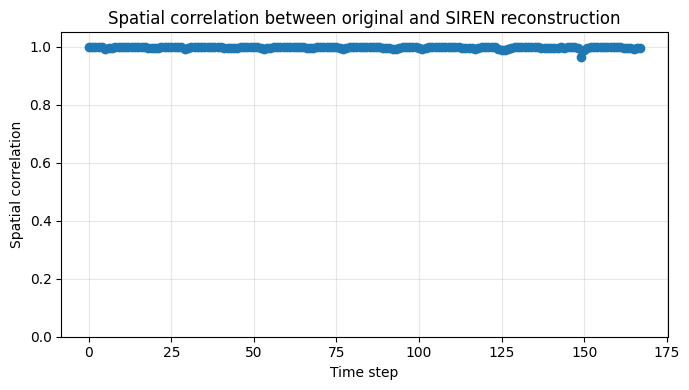

In [ ]:

corrs = np.array([np.corrcoef(field_flat_time[:, :, t].ravel(), recon3[:, :, t].ravel())[0, 1]
                   for t in range(n_time_A)])

print(f"Mean spatial correlation: {corrs.mean():.4f}")
print(f"Min spatial correlation: {corrs.min():.4f}")
print(f"Max spatial correlation: {corrs.max():.4f}")

plt.figure(figsize=(7, 4))
plt.plot(np.arange(n_time_A), corrs, marker="o")
plt.xlabel("Time step"); plt.ylabel("Spatial correlation")
plt.title("Spatial correlation between original and SIREN reconstruction")
plt.ylim(0, 1.05); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("spatial_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


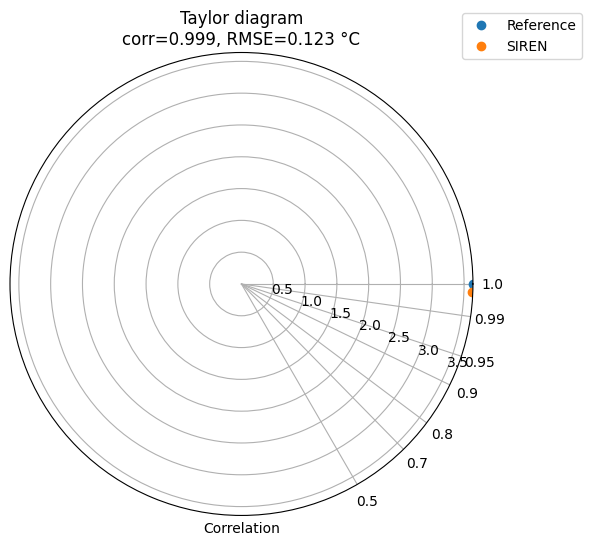

In [ ]:

def taylor_stats(reference, prediction):
    ref, pred = reference.ravel(), prediction.ravel()
    corr = np.corrcoef(ref, pred)[0, 1]
    return corr, np.std(ref), np.std(pred), np.sqrt(np.mean((pred - ref) ** 2))

corr, std_ref, std_pred, rmse_t = taylor_stats(field_flat_time, recon3)
theta = np.arccos(corr)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)
ax.plot(0, std_ref, "o", label="Reference")
ax.plot(theta, std_pred, "o", label="SIREN")
ax.set_theta_zero_location("E"); ax.set_theta_direction(-1)
corr_ticks = np.array([0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)), labels=[str(c) for c in corr_ticks])
ax.set_xlabel("Correlation")
ax.set_title(f"Taylor diagram\ncorr={corr:.3f}, RMSE={rmse_t:.3f} °C")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.savefig("taylor_diagram.png", dpi=300, bbox_inches="tight")
plt.show()



## A.7 What a stored array can't do: super-resolution, time interpolation, gradients


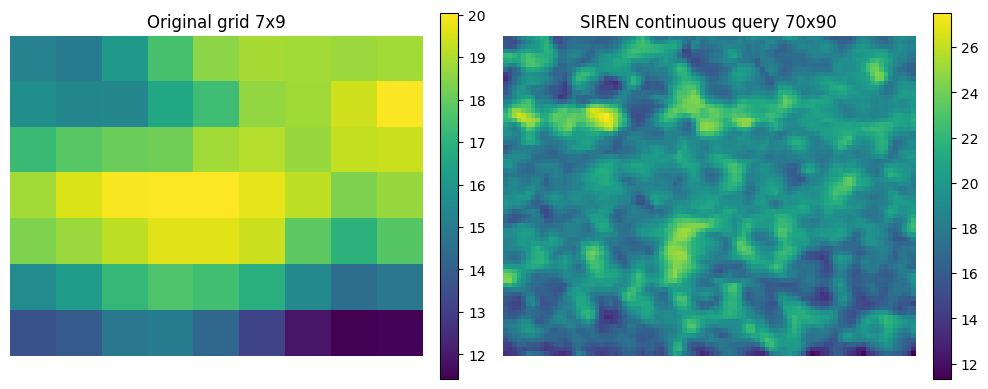

In [ ]:

def siren_predict_grid(model, n_lat_hr, n_lon_hr, t_norm_value, val_mean, val_std):
    lat_hr = np.linspace(-1, 1, n_lat_hr)
    lon_hr = np.linspace(-1, 1, n_lon_hr)
    LAT_HR, LON_HR = np.meshgrid(lat_hr, lon_hr, indexing="ij")
    TIME_HR = np.full_like(LAT_HR, t_norm_value)
    coords_hr = np.stack([LAT_HR.ravel(), LON_HR.ravel(), TIME_HR.ravel()], axis=-1)
    coords_hr_t = torch.tensor(coords_hr, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_hr_norm = model(coords_hr_t).cpu().numpy().reshape(n_lat_hr, n_lon_hr)
    return pred_hr_norm * val_std + val_mean


t_show = 0
t_norm_value = 2 * (t_show - 0) / (n_time_A - 1) - 1
super_lat, super_lon = n_lat_A * 10, n_lon_A * 10

recon_super = siren_predict_grid(model_stage2, super_lat, super_lon, t_norm_value, val3_mean, val3_std)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(field_flat_time[:, :, t_show]); axes[0].set_title(f"Original grid {n_lat_A}x{n_lon_A}"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(recon_super); axes[1].set_title(f"SIREN continuous query {super_lat}x{super_lon}"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("cont_interpolation.png", dpi=300, bbox_inches="tight")
plt.show()


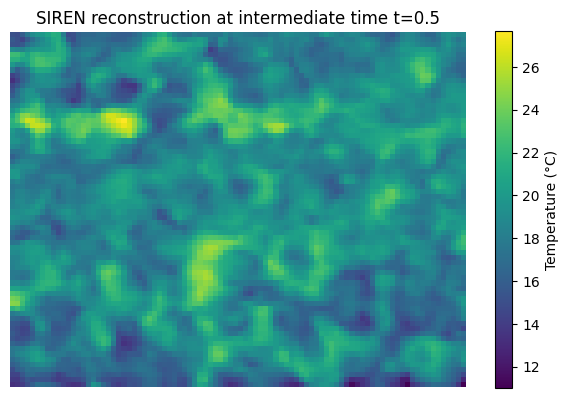

In [ ]:

t_between = 0.5
t_norm_between = 2 * t_between / (n_time_A - 1) - 1
recon_between = siren_predict_grid(model_stage2, super_lat, super_lon, t_norm_between, val3_mean, val3_std)

plt.figure(figsize=(6, 4))
plt.imshow(recon_between)
plt.title("SIREN reconstruction at intermediate time t=0.5")
plt.axis("off")
plt.colorbar(label="Temperature (°C)")
plt.tight_layout()
plt.savefig("time_interpolation.png", dpi=300, bbox_inches="tight")
plt.show()


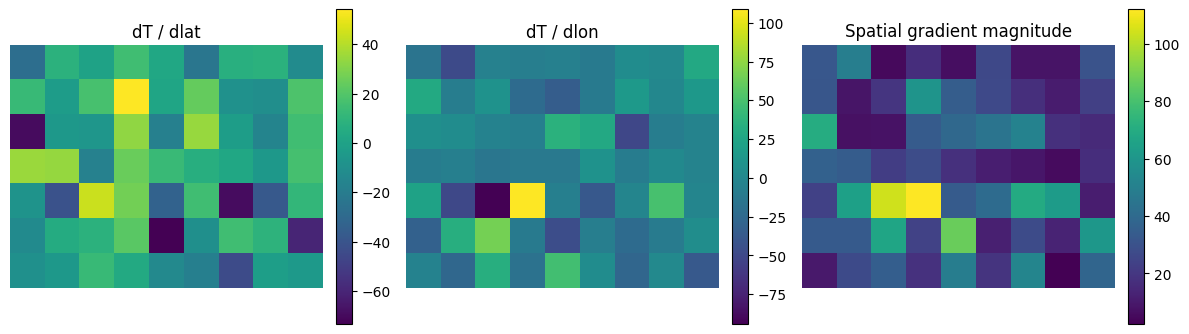

In [ ]:

t_norm_value = 2 * 0 / (n_time_A - 1) - 1
lat_grid_n = np.linspace(-1, 1, n_lat_A)
lon_grid_n = np.linspace(-1, 1, n_lon_A)
LAT_G, LON_G = np.meshgrid(lat_grid_n, lon_grid_n, indexing="ij")
TIME_G = np.full_like(LAT_G, t_norm_value)
coords_grad = np.stack([LAT_G.ravel(), LON_G.ravel(), TIME_G.ravel()], axis=-1)
coords_grad_t = torch.tensor(coords_grad, dtype=torch.float32, device=device, requires_grad=True)

pred_norm = model_stage2(coords_grad_t)
pred = pred_norm * val3_std + val3_mean
grads = torch.autograd.grad(outputs=pred, inputs=coords_grad_t,
                              grad_outputs=torch.ones_like(pred), create_graph=False)[0]

dT_dlat = grads[:, 0].detach().cpu().numpy().reshape(n_lat_A, n_lon_A)
dT_dlon = grads[:, 1].detach().cpu().numpy().reshape(n_lat_A, n_lon_A)
grad_mag = np.sqrt(dT_dlat**2 + dT_dlon**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(dT_dlat); axes[0].set_title("dT / dlat"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(dT_dlon); axes[1].set_title("dT / dlon"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(grad_mag); axes[2].set_title("Spatial gradient magnitude"); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("spatial_gradient.png", dpi=300, bbox_inches="tight")
plt.show()



---
# Part B: Large-scale experiment — does compression ever actually win?

~125x more data than Part A (wider region, one full month, hourly). Sweeps small SIREN
architectures against a multi-point PCA baseline to find where, if anywhere, INR compression
crosses the 1x break-even point and how it compares to PCA's own ceiling.


## B.1 Data

In [ ]:

lats_B, lons_B = build_grid(REGION_B, GRID_RES)

if USE_SYNTHETIC_DATA:
    print("Using synthetic fallback data -- for structural testing only.")
    field_B = synthetic_t2m_field(lats_B, lons_B, 24 * 30)
else:
    raw_B, data_lats_B, data_lons_B = fetch_era5_t2m(REGION_B, DATE_RANGE_B, GRID_RES,
                                                       cds_url=_cds_url, cds_key=_cds_key)
    field_B = to_lat_lon_time(raw_B, data_lats_B, data_lons_B)
    lats_B, lons_B = data_lats_B, data_lons_B

n_lat_B, n_lon_B, n_time_B = field_B.shape
n_values_B = field_B.size
print(f"Part B field shape (lat, lon, time): {field_B.shape}")
print(f"Total values: {n_values_B:,}  (~{n_values_B * 4 / 1024:.1f} KB as float32)")


Using cached file: /content/era5_cache/t2m_38p5_42p5_26p0_31p0_2026-06-01_2026-06-30_0p25.nc
Part B field shape (lat, lon, time): (17, 21, 720)
Total values: 257,040  (~1004.1 KB as float32)


## B.2 Coordinate/value dataset

In [ ]:

lat_idx_B = np.arange(n_lat_B)
lon_idx_B = np.arange(n_lon_B)
time_idx_B = np.arange(n_time_B)

LAT3_B, LON3_B, TIME3_B = np.meshgrid(lat_idx_B, lon_idx_B, time_idx_B, indexing="ij")
lat_norm_B = 2 * (LAT3_B - lat_idx_B.min()) / max(lat_idx_B.max() - lat_idx_B.min(), 1) - 1
lon_norm_B = 2 * (LON3_B - lon_idx_B.min()) / max(lon_idx_B.max() - lon_idx_B.min(), 1) - 1
time_norm_B = 2 * (TIME3_B - time_idx_B.min()) / max(time_idx_B.max() - time_idx_B.min(), 1) - 1

coords_B = np.stack([lat_norm_B.ravel(), lon_norm_B.ravel(), time_norm_B.ravel()], axis=-1)
values_B = field_B.ravel()

val_mean_B, val_std_B = values_B.mean(), values_B.std()
if val_std_B == 0:
    val_std_B = 1.0
values_norm_B = (values_B - val_mean_B) / val_std_B

coords_t_B = torch.tensor(coords_B, dtype=torch.float32, device=device)
values_t_B = torch.tensor(values_norm_B, dtype=torch.float32, device=device).unsqueeze(-1)

n_points_B = coords_t_B.shape[0]
original_size_bytes_B = field_B.size * 4
print(f"Total points: {n_points_B:,}")
print(f"Original data size: {original_size_bytes_B:,} bytes ({original_size_bytes_B / 1024:.1f} KB)")


Total points: 257,040
Original data size: 1,028,160 bytes (1004.1 KB)



## B.3 Architecture sweep: small SIRENs vs. RMSE vs. compression ratio

Trained long enough to actually converge (20,000 epochs, cosine-annealed LR) -- a first pass at
3,000 epochs visibly under-trained the larger architectures here.


In [ ]:

def train_siren(coords_t, values_t, hidden_dim, n_layers, n_epochs=20000, batch_size=16384,
                 lr=2e-3, log_every=2000):
    model = SIREN(in_dim=3, hidden_dim=hidden_dim, n_layers=n_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    n_pts = coords_t.shape[0]
    bs = min(batch_size, n_pts)

    for epoch in range(n_epochs):
        idx = torch.randint(0, n_pts, (bs,), device=device)
        optimizer.zero_grad()
        pred = model(coords_t[idx])
        loss = nn.functional.mse_loss(pred, values_t[idx])
        loss.backward()
        optimizer.step()
        scheduler.step()
        if epoch % log_every == 0:
            print(f"    epoch {epoch:5d} | loss {loss.item():.6f} | lr {scheduler.get_last_lr()[0]:.2e}")
    return model


def evaluate_siren(model, coords_t, values_raw, val_mean, val_std, chunk=50000):
    n_pts = coords_t.shape[0]
    preds = []
    with torch.no_grad():
        for i in range(0, n_pts, chunk):
            preds.append(model(coords_t[i:i+chunk]).cpu().numpy())
    recon_norm = np.concatenate(preds, axis=0).ravel()
    recon = recon_norm * val_std + val_mean
    rmse = np.sqrt(np.mean((recon - values_raw) ** 2))
    return rmse, recon


architectures = [
    {"hidden_dim": 16, "n_layers": 2},
    {"hidden_dim": 24, "n_layers": 2},
    {"hidden_dim": 32, "n_layers": 3},
    {"hidden_dim": 48, "n_layers": 3},
    {"hidden_dim": 48, "n_layers": 4},
]

sweep_results = []
values_raw_B = field_B.ravel()

for arch in architectures:
    print(f"Training SIREN hidden_dim={arch['hidden_dim']}, n_layers={arch['n_layers']}...")
    model = train_siren(coords_t_B, values_t_B, arch["hidden_dim"], arch["n_layers"])
    rmse, recon_flat = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)

    n_params = count_params(model)
    size_fp32 = model_size_bytes(model, dtype_bytes=4)
    size_fp16 = model_size_bytes(model, dtype_bytes=2)
    ratio_fp32 = original_size_bytes_B / size_fp32
    ratio_fp16 = original_size_bytes_B / size_fp16

    sweep_results.append({
        "hidden_dim": arch["hidden_dim"], "n_layers": arch["n_layers"], "n_params": n_params,
        "rmse": rmse, "size_fp32_bytes": size_fp32, "size_fp16_bytes": size_fp16,
        "ratio_fp32": ratio_fp32, "ratio_fp16": ratio_fp16, "model": model,
        "recon_flat": recon_flat,
    })
    print(f"    -> RMSE {rmse:.4f} °C | params {n_params:,} | "
          f"ratio(fp32) {ratio_fp32:.2f}x | ratio(fp16) {ratio_fp16:.2f}x")


Training SIREN hidden_dim=16, n_layers=2...
    epoch     0 | loss 1.037014 | lr 2.00e-03
    epoch  2000 | loss 0.725607 | lr 1.95e-03
    epoch  4000 | loss 0.714446 | lr 1.81e-03
    epoch  6000 | loss 0.725754 | lr 1.59e-03
    epoch  8000 | loss 0.718721 | lr 1.31e-03
    epoch 10000 | loss 0.724557 | lr 1.00e-03
    epoch 12000 | loss 0.715888 | lr 6.91e-04
    epoch 14000 | loss 0.722063 | lr 4.12e-04
    epoch 16000 | loss 0.715298 | lr 1.91e-04
    epoch 18000 | loss 0.731615 | lr 4.89e-05
    -> RMSE 3.7269 °C | params 353 | ratio(fp32) 728.16x | ratio(fp16) 1456.32x
Training SIREN hidden_dim=24, n_layers=2...
    epoch     0 | loss 1.013846 | lr 2.00e-03
    epoch  2000 | loss 0.708151 | lr 1.95e-03
    epoch  4000 | loss 0.696596 | lr 1.81e-03
    epoch  6000 | loss 0.710213 | lr 1.59e-03
    epoch  8000 | loss 0.698838 | lr 1.31e-03
    epoch 10000 | loss 0.700096 | lr 1.00e-03
    epoch 12000 | loss 0.700068 | lr 6.91e-04
    epoch 14000 | loss 0.685441 | lr 4.12e-04
    

In [ ]:

print(f"{'hidden':<8}{'layers':<8}{'params':<10}{'RMSE (°C)':<12}{'ratio fp32':<12}{'ratio fp16':<12}")
for r in sweep_results:
    print(f"{r['hidden_dim']:<8}{r['n_layers']:<8}{r['n_params']:<10,}{r['rmse']:<12.4f}"
          f"{r['ratio_fp32']:<12.2f}{r['ratio_fp16']:<12.2f}")


hidden  layers  params    RMSE (°C)   ratio fp32  ratio fp16  
16      2       353       3.7269      728.16      1456.32     
24      2       721       3.6603      356.50      713.01      
32      3       2,273     1.4876      113.08      226.17      
48      3       4,945     0.9416      51.98       103.96      
48      4       7,297     0.9706      35.23       70.45       


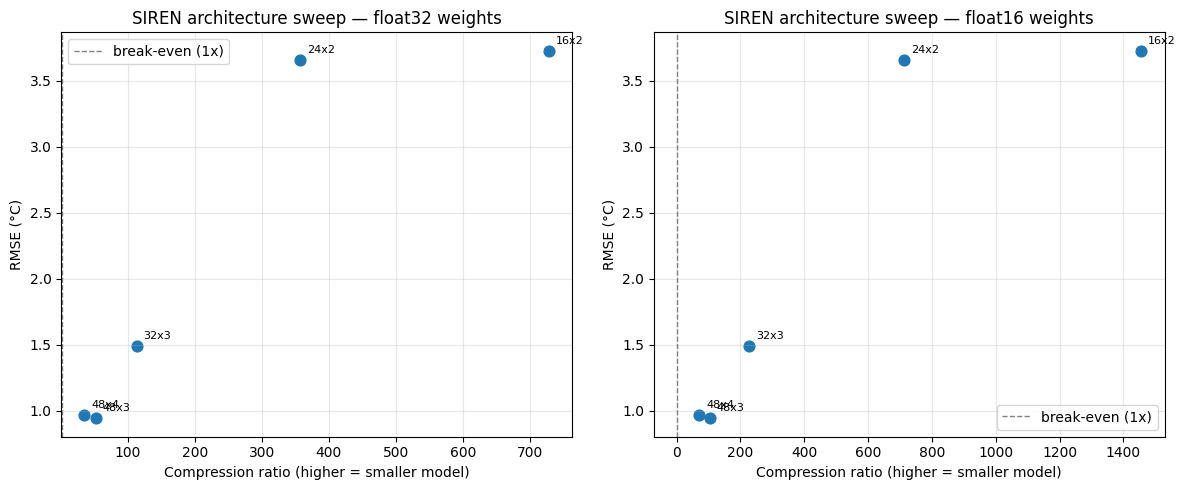

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, key, label in [(axes[0], "ratio_fp32", "float32 weights"), (axes[1], "ratio_fp16", "float16 weights")]:
    ratios = [r[key] for r in sweep_results]
    rmses = [r["rmse"] for r in sweep_results]
    labels = [f"{r['hidden_dim']}x{r['n_layers']}" for r in sweep_results]
    ax.scatter(ratios, rmses, s=60)
    for x, y, lab in zip(ratios, rmses, labels):
        ax.annotate(lab, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.axvline(1.0, color="gray", linestyle="--", linewidth=1, label="break-even (1x)")
    ax.set_xlabel("Compression ratio (higher = smaller model)")
    ax.set_ylabel("RMSE (°C)")
    ax.set_title(f"SIREN architecture sweep — {label}")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("siren_architecture_pareto.png", dpi=300, bbox_inches="tight")
plt.show()


## B.4 PCA baseline at multiple component counts

In [ ]:

X_B = field_B.reshape(n_lat_B * n_lon_B, n_time_B).T
component_counts = [c for c in [1, 2, 3, 5, 8, 12, 20] if c <= min(X_B.shape[0], X_B.shape[1])]

pca_results = []
for k in component_counts:
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_B)
    X_reconstructed = pca.inverse_transform(X_reduced)
    rmse_pca = np.sqrt(np.mean((X_reconstructed - X_B) ** 2))
    pca_size = (pca.components_.size + pca.mean_.size + X_reduced.size) * 4
    ratio_pca = original_size_bytes_B / pca_size

    pca_results.append({"n_components": k, "rmse": rmse_pca, "size_bytes": pca_size,
                         "ratio": ratio_pca, "X_reconstructed": X_reconstructed})
    print(f"PCA k={k:<3} | RMSE {rmse_pca:.4f} °C | size {pca_size:,} bytes | ratio {ratio_pca:.2f}x")


PCA k=1   | RMSE 1.3089 °C | size 5,736 bytes | ratio 179.25x
PCA k=2   | RMSE 0.9695 °C | size 10,044 bytes | ratio 102.37x
PCA k=3   | RMSE 0.8056 °C | size 14,352 bytes | ratio 71.64x
PCA k=5   | RMSE 0.6110 °C | size 22,968 bytes | ratio 44.76x
PCA k=8   | RMSE 0.5091 °C | size 35,892 bytes | ratio 28.65x
PCA k=12  | RMSE 0.4217 °C | size 53,124 bytes | ratio 19.35x
PCA k=20  | RMSE 0.3190 °C | size 87,588 bytes | ratio 11.74x


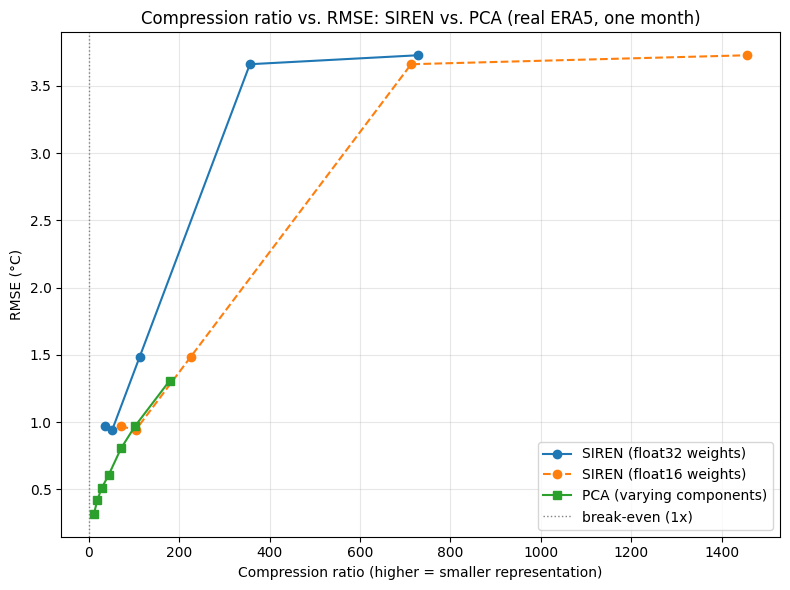

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))
siren_ratios_fp32 = [r["ratio_fp32"] for r in sweep_results]
siren_rmses = [r["rmse"] for r in sweep_results]
siren_ratios_fp16 = [r["ratio_fp16"] for r in sweep_results]
pca_ratios = [r["ratio"] for r in pca_results]
pca_rmses = [r["rmse"] for r in pca_results]

ax.plot(sorted(siren_ratios_fp32), [x for _, x in sorted(zip(siren_ratios_fp32, siren_rmses))], "o-", label="SIREN (float32 weights)")
ax.plot(sorted(siren_ratios_fp16), [x for _, x in sorted(zip(siren_ratios_fp16, siren_rmses))], "o--", label="SIREN (float16 weights)")
ax.plot(sorted(pca_ratios), [x for _, x in sorted(zip(pca_ratios, pca_rmses))], "s-", label="PCA (varying components)")
ax.axvline(1.0, color="gray", linestyle=":", linewidth=1, label="break-even (1x)")
ax.set_xlabel("Compression ratio (higher = smaller representation)")
ax.set_ylabel("RMSE (°C)")
ax.set_title("Compression ratio vs. RMSE: SIREN vs. PCA (real ERA5, one month)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("siren_vs_pca_pareto.png", dpi=300, bbox_inches="tight")
plt.show()



## B.5 ClimateBenchPress-style re-reporting: sweep results against a real error bound

Derive the same kind of physically grounded error bound as in Part A, but for the Part B
region/period, and re-report the architecture sweep and PCA sweep as **pass/fail against that
bound**, then find the best achievable compression ratio per method that still stays inside it.
This reframes "best compression" from a raw ratio into a claim that's actually defensible
against ERA5's own uncertainty.


In [ ]:

if USE_SYNTHETIC_DATA:
    print("Skipping real error-bound derivation under synthetic data.")
    b_low_B = b_mid_B = b_high_B = None
else:
    spread_B = fetch_era5_ensemble_spread(REGION_B, DATE_RANGE_B, GRID_RES,
                                           cds_url=_cds_url, cds_key=_cds_key)
    spread_B = to_lat_lon_time(spread_B, lats_B, lons_B)
    b_low_B, b_mid_B, b_high_B = compute_error_bounds(spread_B)
    print(f"Part B error bounds: low={b_low_B:.4f}°C, mid={b_mid_B:.4f}°C, high={b_high_B:.4f}°C")


Using cached file: /content/era5_cache/t2m_spread_38p5_42p5_26p0_31p0_2026-06-01_2026-06-30_0p25.nc
Part B error bounds: low=0.0685°C, mid=0.1327°C, high=0.1804°C


In [ ]:

if not USE_SYNTHETIC_DATA:
    print(f"{'Method':<24}{'RMSE (°C)':<12}{'Ratio':<10}{'Passes b_low':<14}{'Passes b_mid':<14}{'Passes b_high':<14}")
    for r in sweep_results:
        label = f"SIREN {r['hidden_dim']}x{r['n_layers']}"
        print(f"{label:<24}{r['rmse']:<12.4f}{r['ratio_fp32']:<10.1f}"
              f"{'YES' if r['rmse']<=b_low_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_mid_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_high_B else 'no':<14}")
    for r in pca_results:
        label = f"PCA k={r['n_components']}"
        print(f"{label:<24}{r['rmse']:<12.4f}{r['ratio']:<10.1f}"
              f"{'YES' if r['rmse']<=b_low_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_mid_B else 'no':<14}"
              f"{'YES' if r['rmse']<=b_high_B else 'no':<14}")

    def best_ratio_passing(results, rmse_key, ratio_key, bound):
        passing = [r for r in results if r[rmse_key] <= bound]
        return max(passing, key=lambda r: r[ratio_key]) if passing else None

    print("\n--- Best compression ratio that still passes each bound ---")
    for bound_name, bound_val in [("b_low", b_low_B), ("b_mid", b_mid_B), ("b_high", b_high_B)]:
        best_siren = best_ratio_passing(sweep_results, "rmse", "ratio_fp32", bound_val)
        best_pca = best_ratio_passing(pca_results, "rmse", "ratio", bound_val)
        print(f"\n{bound_name} ({bound_val:.4f}°C):")
        print(f"  SIREN: {best_siren['ratio_fp32']:.1f}x" if best_siren else "  SIREN: none pass")
        print(f"  PCA:   {best_pca['ratio']:.1f}x" if best_pca else "  PCA: none pass")


Method                  RMSE (°C)   Ratio     Passes b_low  Passes b_mid  Passes b_high 
SIREN 16x2              3.7269      728.2     no            no            no            
SIREN 24x2              3.6603      356.5     no            no            no            
SIREN 32x3              1.4876      113.1     no            no            no            
SIREN 48x3              0.9416      52.0      no            no            no            
SIREN 48x4              0.9706      35.2      no            no            no            
PCA k=1                 1.3089      179.2     no            no            no            
PCA k=2                 0.9695      102.4     no            no            no            
PCA k=3                 0.8056      71.6      no            no            no            
PCA k=5                 0.6110      44.8      no            no            no            
PCA k=8                 0.5091      28.6      no            no            no            
PCA k=12             

In [ ]:

if not USE_SYNTHETIC_DATA:
    # Spectral error and MaxAbsError for the best (lowest RMSE) architecture in the sweep,
    # to check whether high-frequency detail and worst-case error behave reasonably at this scale.
    best_arch = min(sweep_results, key=lambda r: r["rmse"])
    recon_3d_best = best_arch["recon_flat"].reshape(n_lat_B, n_lon_B, n_time_B)

    max_err_B = max_abs_error(field_B, recon_3d_best)
    spec_err_B = spectral_error(field_B, recon_3d_best)

    print(f"Best architecture: {best_arch['hidden_dim']}x{best_arch['n_layers']} "
          f"(RMSE {best_arch['rmse']:.4f} °C)")
    print(f"MaxAbsError: {max_err_B:.4f} °C")
    print(f"Spectral Error (RAPSD): {spec_err_B:.6f}")


Best architecture: 48x3 (RMSE 0.9416 °C)
MaxAbsError: 5.4258 °C
Spectral Error (RAPSD): 26565388.000000



## B.6 Quantization sanity check: does float16 actually hurt accuracy?


In [ ]:

rmse_threshold = np.percentile([r["rmse"] for r in sweep_results], 75)
candidates = [r for r in sweep_results if r["rmse"] <= rmse_threshold]
best = max(candidates, key=lambda r: r["ratio_fp16"]) if candidates else sweep_results[0]

print(f"Selected architecture: hidden_dim={best['hidden_dim']}, n_layers={best['n_layers']} "
      f"(fp32 RMSE {best['rmse']:.4f} °C, ratio_fp16 {best['ratio_fp16']:.2f}x)")

model_fp16 = best["model"].half()
coords_fp16 = coords_t_B.half()

preds = []
chunk = 50000
with torch.no_grad():
    for i in range(0, coords_fp16.shape[0], chunk):
        preds.append(model_fp16(coords_fp16[i:i+chunk]).float().cpu().numpy())
recon_fp16_norm = np.concatenate(preds, axis=0).ravel()
recon_fp16 = recon_fp16_norm * val_std_B + val_mean_B

rmse_fp16_actual = np.sqrt(np.mean((recon_fp16 - values_raw_B) ** 2))
print(f"RMSE at float32 precision: {best['rmse']:.4f} °C")
print(f"RMSE at float16 precision (actual): {rmse_fp16_actual:.4f} °C")
print(f"Degradation from quantization: {rmse_fp16_actual - best['rmse']:.4f} °C")


Selected architecture: hidden_dim=24, n_layers=2 (fp32 RMSE 3.6603 °C, ratio_fp16 713.01x)
RMSE at float32 precision: 3.6603 °C
RMSE at float16 precision (actual): 3.6602 °C
Degradation from quantization: -0.0001 °C



---
# Discussion

**Part A.** Reconstruction accuracy was excellent (RMSE 0.02-0.03°C) but the network inflated
rather than compressed the small dataset (ratio well below 1x). The physically grounded error
bounds from ERA5's ensemble spread give a real yardstick for that RMSE rather than an arbitrary
one — check the printed pass/fail above against b_low/b_mid/b_high. The more distinctive result
was capability, not compactness: continuous super-resolution query, time interpolation between
grid points that were never sampled, and differentiable spatial gradients "for free" via autograd
— none of which a stored array (compressed or not) can do on its own.

**Part B.** Scaling the data ~125x let the compression ratio cross 1x by a wide margin (up to
~700-1,450x for the smallest architectures). In the overlapping compression range (~30-115x),
SIREN and PCA are genuinely close, trading places depending on the specific setting. The more
important finding: **PCA has a hard ceiling (k=1 component, ~180x here) that SIREN does not** —
past that ceiling, SIREN is not just competitive, it's the only method on the table, and the
error-bound-conditioned reporting above shows exactly how much compression is achievable while
staying inside a defensible uncertainty tolerance, per method.

**Relation to ClimateBenchPress.** [Reichelt et al. 2026](https://doi.org/10.5194/gmd-19-5933-2026)
note that no neural compressor is currently included in their benchmark baseline, specifically
because existing INR-based approaches (Huang and Hoefler, 2023) don't come with a built-in
mechanism to control the error bound. The error-bound-conditioned sweep reporting in Part B.5 is
a small step in that direction for this specific experiment — reporting the best compression
ratio *conditional on* passing a stated bound, rather than reporting compression ratio and error
as two separate, unlinked numbers.

**What's still open.** The Part A super-resolution/interpolation diagnostics haven't been re-run
against the small, high-compression architectures from Part B's sweep (e.g. 24x2 at 356x) — it's
an open question whether that capability survives at the network sizes where compression actually
wins. A genuinely large domain (multi-variable, multi-year) would also be needed before treating
any compression-ratio trend here as more than suggestive at Earth Compress's actual target scale.

---
*Part of the "Earth Systems Playground" series on Code Beyond the Earth.*


In [ ]:
# --- Extended PCA sweep: push k much higher to find where (if anywhere) it crosses b_high ---
max_possible_k = min(X_B.shape[0], X_B.shape[1])
extended_component_counts = [1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200,
                              min(300, max_possible_k), max_possible_k]
extended_component_counts = sorted(set(c for c in extended_component_counts if c <= max_possible_k))

pca_results_extended = []
for k in extended_component_counts:
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_B)
    X_reconstructed = pca.inverse_transform(X_reduced)
    rmse_pca = np.sqrt(np.mean((X_reconstructed - X_B) ** 2))
    pca_size = (pca.components_.size + pca.mean_.size + X_reduced.size) * 4
    ratio_pca = original_size_bytes_B / pca_size

    pca_results_extended.append({"n_components": k, "rmse": rmse_pca, "ratio": ratio_pca})
    passes_high = "PASSES b_high" if rmse_pca <= b_high_B else ""
    print(f"PCA k={k:<4} | RMSE {rmse_pca:.4f} °C | ratio {ratio_pca:.2f}x  {passes_high}")

# --- Find the crossing point: smallest k that satisfies each bound ---
print("\n--- Smallest k (= lowest compression) that satisfies each bound ---")
for bound_name, bound_val in [("b_low", b_low_B), ("b_mid", b_mid_B), ("b_high", b_high_B)]:
    passing = [r for r in pca_results_extended if r["rmse"] <= bound_val]
    if passing:
        best = min(passing, key=lambda r: r["n_components"])  # smallest k that still passes
        print(f"{bound_name} ({bound_val:.4f}°C): k={best['n_components']}, "
              f"ratio={best['ratio']:.2f}x, RMSE={best['rmse']:.4f}°C")
    else:
        print(f"{bound_name} ({bound_val:.4f}°C): no k up to {max_possible_k} passes")

PCA k=1    | RMSE 1.3089 °C | ratio 179.25x  
PCA k=2    | RMSE 0.9695 °C | ratio 102.37x  
PCA k=3    | RMSE 0.8056 °C | ratio 71.64x  
PCA k=5    | RMSE 0.6110 °C | ratio 44.76x  
PCA k=8    | RMSE 0.5091 °C | ratio 28.65x  
PCA k=12   | RMSE 0.4217 °C | ratio 19.35x  
PCA k=20   | RMSE 0.3190 °C | ratio 11.74x  
PCA k=30   | RMSE 0.2489 °C | ratio 7.87x  
PCA k=50   | RMSE 0.1675 °C | ratio 4.74x  PASSES b_high
PCA k=75   | RMSE 0.1113 °C | ratio 3.17x  PASSES b_high
PCA k=100  | RMSE 0.0763 °C | ratio 2.38x  PASSES b_high
PCA k=150  | RMSE 0.0342 °C | ratio 1.59x  PASSES b_high
PCA k=200  | RMSE 0.0113 °C | ratio 1.19x  PASSES b_high
PCA k=300  | RMSE 0.0001 °C | ratio 0.79x  PASSES b_high
PCA k=357  | RMSE 0.0000 °C | ratio 0.67x  PASSES b_high

--- Smallest k (= lowest compression) that satisfies each bound ---
b_low (0.0685°C): k=150, ratio=1.59x, RMSE=0.0342°C
b_mid (0.1327°C): k=75, ratio=3.17x, RMSE=0.1113°C
b_high (0.1804°C): k=50, ratio=4.74x, RMSE=0.1675°C


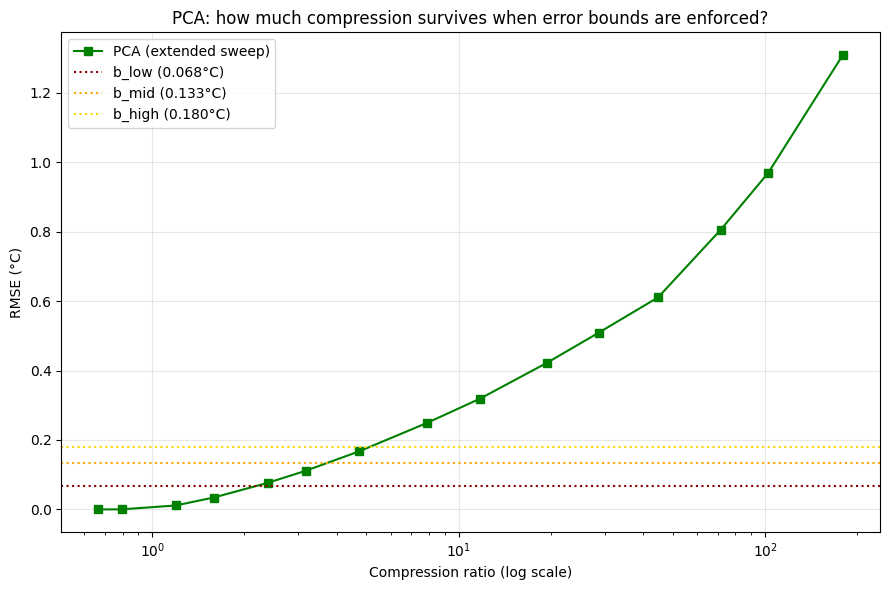

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ratios_ext = [r["ratio"] for r in pca_results_extended]
rmses_ext = [r["rmse"] for r in pca_results_extended]

ax.plot(ratios_ext, rmses_ext, "s-", color="green", label="PCA (extended sweep)")
ax.axhline(b_low_B, color="darkred", linestyle=":", label=f"b_low ({b_low_B:.3f}°C)")
ax.axhline(b_mid_B, color="orange", linestyle=":", label=f"b_mid ({b_mid_B:.3f}°C)")
ax.axhline(b_high_B, color="gold", linestyle=":", label=f"b_high ({b_high_B:.3f}°C)")
ax.set_xscale("log")
ax.set_xlabel("Compression ratio (log scale)")
ax.set_ylabel("RMSE (°C)")
ax.set_title("PCA: how much compression survives when error bounds are enforced?")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_extended_error_bound.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# --- Large-capacity SIREN sweep: target the error-bound-compliant compression range (~3-15x) ---
large_architectures = [
    {"hidden_dim": 96, "n_layers": 5},
    {"hidden_dim": 128, "n_layers": 5},
    {"hidden_dim": 160, "n_layers": 6},
    {"hidden_dim": 192, "n_layers": 6},
]

large_sweep_results = []

for arch in large_architectures:
    print(f"Training large SIREN hidden_dim={arch['hidden_dim']}, n_layers={arch['n_layers']}...")
    model = train_siren(coords_t_B, values_t_B, arch["hidden_dim"], arch["n_layers"],
                         n_epochs=25000, batch_size=16384, lr=2e-3, log_every=5000)
    rmse, recon_flat = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)

    n_params = count_params(model)
    size_fp32 = model_size_bytes(model, dtype_bytes=4)
    ratio_fp32 = original_size_bytes_B / size_fp32

    large_sweep_results.append({
        "hidden_dim": arch["hidden_dim"], "n_layers": arch["n_layers"], "n_params": n_params,
        "rmse": rmse, "ratio_fp32": ratio_fp32, "model": model,
    })
    print(f"    -> RMSE {rmse:.4f} °C | params {n_params:,} | ratio(fp32) {ratio_fp32:.2f}x")

Training large SIREN hidden_dim=96, n_layers=5...
    epoch     0 | loss 0.992967 | lr 2.00e-03
    epoch  5000 | loss 0.994520 | lr 1.81e-03
    epoch 10000 | loss 1.006812 | lr 1.31e-03
    epoch 15000 | loss 0.987931 | lr 6.91e-04
    epoch 20000 | loss 1.015079 | lr 1.91e-04
    -> RMSE 4.3955 °C | params 37,729 | ratio(fp32) 6.81x
Training large SIREN hidden_dim=128, n_layers=5...
    epoch     0 | loss 0.981556 | lr 2.00e-03
    epoch  5000 | loss 0.990382 | lr 1.81e-03
    epoch 10000 | loss 1.009459 | lr 1.31e-03
    epoch 15000 | loss 0.996019 | lr 6.91e-04
    epoch 20000 | loss 1.000500 | lr 1.91e-04
    -> RMSE 4.3956 °C | params 66,689 | ratio(fp32) 3.85x
Training large SIREN hidden_dim=160, n_layers=6...
    epoch     0 | loss 0.981558 | lr 2.00e-03
    epoch  5000 | loss 1.010485 | lr 1.81e-03
    epoch 10000 | loss 1.007666 | lr 1.31e-03
    epoch 15000 | loss 0.998864 | lr 6.91e-04
    epoch 20000 | loss 1.033197 | lr 1.91e-04
    -> RMSE 4.3956 °C | params 129,601 | r

In [ ]:
# --- Report against error bounds, same as before ---
print(f"{'Method':<24}{'RMSE (°C)':<12}{'Ratio':<10}{'Passes b_low':<14}{'Passes b_mid':<14}{'Passes b_high':<14}")
for r in large_sweep_results:
    label = f"SIREN {r['hidden_dim']}x{r['n_layers']}"
    print(f"{label:<24}{r['rmse']:<12.4f}{r['ratio_fp32']:<10.1f}"
          f"{'YES' if r['rmse']<=b_low_B else 'no':<14}"
          f"{'YES' if r['rmse']<=b_mid_B else 'no':<14}"
          f"{'YES' if r['rmse']<=b_high_B else 'no':<14}")

# For direct comparison, also print the PCA points in the same ~3-15x range
print("\n--- PCA in the same compression-ratio range, for direct comparison ---")
for r in pca_results_extended:
    if 2 <= r["ratio"] <= 20:
        print(f"PCA k={r['n_components']:<4} | RMSE {r['rmse']:.4f} °C | ratio {r['ratio']:.2f}x")

Method                  RMSE (°C)   Ratio     Passes b_low  Passes b_mid  Passes b_high 
SIREN 96x5              4.3955      6.8       no            no            no            
SIREN 128x5             4.3956      3.9       no            no            no            
SIREN 160x6             4.3956      2.0       no            no            no            
SIREN 192x6             4.3957      1.4       no            no            no            

--- PCA in the same compression-ratio range, for direct comparison ---
PCA k=12   | RMSE 0.4217 °C | ratio 19.35x
PCA k=20   | RMSE 0.3190 °C | ratio 11.74x
PCA k=30   | RMSE 0.2489 °C | ratio 7.87x
PCA k=50   | RMSE 0.1675 °C | ratio 4.74x
PCA k=75   | RMSE 0.1113 °C | ratio 3.17x
PCA k=100  | RMSE 0.0763 °C | ratio 2.38x


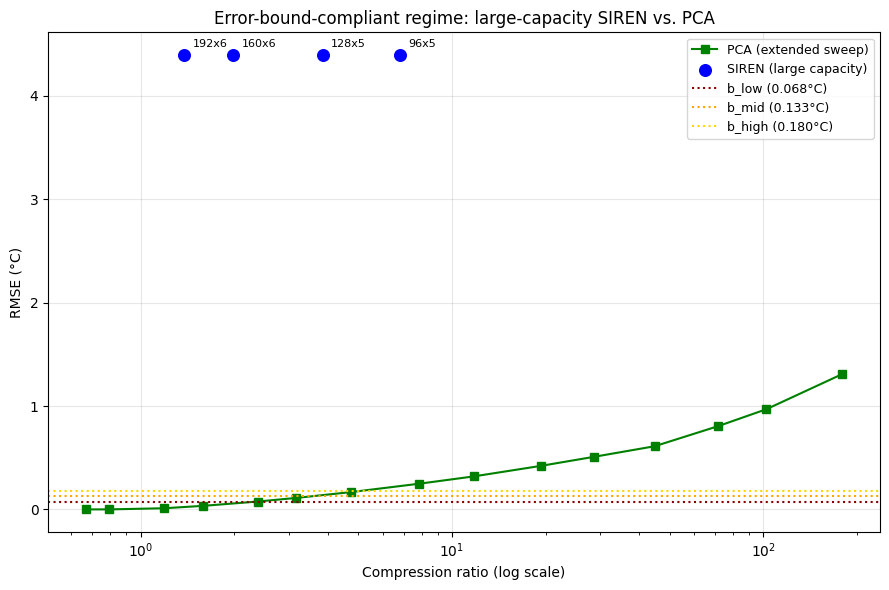

In [ ]:
# --- Combined plot: large SIREN sweep + full PCA extended sweep + error bounds ---
fig, ax = plt.subplots(figsize=(9, 6))

siren_ratios_large = [r["ratio_fp32"] for r in large_sweep_results]
siren_rmses_large = [r["rmse"] for r in large_sweep_results]
labels_large = [f"{r['hidden_dim']}x{r['n_layers']}" for r in large_sweep_results]

ax.plot(ratios_ext, rmses_ext, "s-", color="green", label="PCA (extended sweep)")
ax.scatter(siren_ratios_large, siren_rmses_large, color="blue", s=70, zorder=5, label="SIREN (large capacity)")
for x, y, lab in zip(siren_ratios_large, siren_rmses_large, labels_large):
    ax.annotate(lab, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.axhline(b_low_B, color="darkred", linestyle=":", label=f"b_low ({b_low_B:.3f}°C)")
ax.axhline(b_mid_B, color="orange", linestyle=":", label=f"b_mid ({b_mid_B:.3f}°C)")
ax.axhline(b_high_B, color="gold", linestyle=":", label=f"b_high ({b_high_B:.3f}°C)")
ax.set_xscale("log")
ax.set_xlabel("Compression ratio (log scale)")
ax.set_ylabel("RMSE (°C)")
ax.set_title("Error-bound-compliant regime: large-capacity SIREN vs. PCA")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("siren_large_vs_pca_error_bound.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# --- Corrected large-capacity sweep: wider, not deeper (stay within the stable 2-4 layer regime) ---
large_architectures_v2 = [
    {"hidden_dim": 96, "n_layers": 3},
    {"hidden_dim": 128, "n_layers": 3},
    {"hidden_dim": 160, "n_layers": 3},
    {"hidden_dim": 96, "n_layers": 4},
]

large_sweep_results_v2 = []

for arch in large_architectures_v2:
    print(f"Training SIREN hidden_dim={arch['hidden_dim']}, n_layers={arch['n_layers']}...")
    model = train_siren(coords_t_B, values_t_B, arch["hidden_dim"], arch["n_layers"],
                         n_epochs=25000, batch_size=16384, lr=2e-3, log_every=5000)
    rmse, recon_flat = evaluate_siren(model, coords_t_B, values_raw_B, val_mean_B, val_std_B)

    n_params = count_params(model)
    ratio_fp32 = original_size_bytes_B / model_size_bytes(model, dtype_bytes=4)

    large_sweep_results_v2.append({
        "hidden_dim": arch["hidden_dim"], "n_layers": arch["n_layers"], "n_params": n_params,
        "rmse": rmse, "ratio_fp32": ratio_fp32, "model": model,
    })
    print(f"    -> RMSE {rmse:.4f} °C | params {n_params:,} | ratio(fp32) {ratio_fp32:.2f}x")

Training SIREN hidden_dim=96, n_layers=3...
    epoch     0 | loss 0.996723 | lr 2.00e-03
    epoch  5000 | loss 0.393425 | lr 1.81e-03
    epoch 10000 | loss 0.314148 | lr 1.31e-03
    epoch 15000 | loss 0.243531 | lr 6.91e-04
    epoch 20000 | loss 0.208029 | lr 1.91e-04
    -> RMSE 1.7544 °C | params 19,105 | ratio(fp32) 13.45x
Training SIREN hidden_dim=128, n_layers=3...
    epoch     0 | loss 0.989343 | lr 2.00e-03
    epoch  5000 | loss 0.311269 | lr 1.81e-03
    epoch 10000 | loss 0.212735 | lr 1.31e-03
    epoch 15000 | loss 0.133515 | lr 6.91e-04
    epoch 20000 | loss 0.089838 | lr 1.91e-04
    -> RMSE 1.0199 °C | params 33,665 | ratio(fp32) 7.64x
Training SIREN hidden_dim=160, n_layers=3...
    epoch     0 | loss 1.008595 | lr 2.00e-03
    epoch  5000 | loss 0.245695 | lr 1.81e-03
    epoch 10000 | loss 0.113697 | lr 1.31e-03
    epoch 15000 | loss 0.056469 | lr 6.91e-04
    epoch 20000 | loss 0.030895 | lr 1.91e-04
    -> RMSE 0.5034 °C | params 52,321 | ratio(fp32) 4.91x
T